<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/experiment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device Registered Successfully
Device ID: Parking_Sensor_001

Authenticating Device...
Authentication Successful

Average Occupancy = 32.2

Parking Data
   Time  OccupiedSlots     Status
0     1             12     Normal
1     2             18     Normal
2     3             24     Normal
3     4             31     Normal
4     5             39     Normal
5     6             44     Normal
6     7             47  Congested
7     8             49  Congested
8     9             36     Normal
9    10             22     Normal

CSV File Saved Successfully


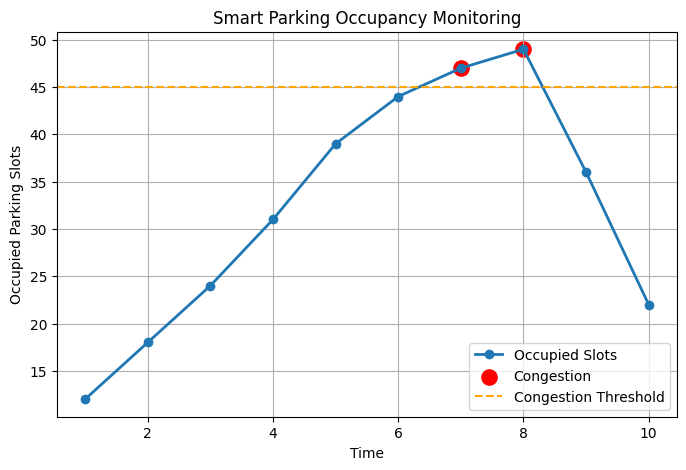


Experiment Completed Successfully


In [1]:
# Experiment 3: Device Onboarding and Data Flow in AWS IoT Core (Simulation)

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Step 1: Device Registration
# -----------------------------------
device_id = "Parking_Sensor_001"
print("Device Registered Successfully")
print("Device ID:", device_id)

# -----------------------------------
# Step 2: Device Authentication
# -----------------------------------
print("\nAuthenticating Device...")

authenticated = True

if authenticated:
    print("Authentication Successful\n")
else:
    print("Authentication Failed")

# -----------------------------------
# Step 3: Generate Parking Data
# -----------------------------------

time = [1,2,3,4,5,6,7,8,9,10]

# Changed dataset only
occupied_slots = [12,18,24,31,39,44,47,49,36,22]

total_slots = 50

# Create DataFrame
df = pd.DataFrame({
    "Time": time,
    "OccupiedSlots": occupied_slots
})

# -----------------------------------
# Step 4: Cloud Analytics
# -----------------------------------

mean_occupancy = df["OccupiedSlots"].mean()

print("Average Occupancy =", mean_occupancy)

# Congestion Detection
df["Status"] = df["OccupiedSlots"].apply(
    lambda x: "Congested" if x >= 45 else "Normal"
)

print("\nParking Data")
print(df)

# -----------------------------------
# Step 5: Save CSV
# -----------------------------------

df.to_csv("parking_data.csv", index=False)

print("\nCSV File Saved Successfully")

# -----------------------------------
# Step 6: Plot Graph
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(df["Time"],
         df["OccupiedSlots"],
         marker='o',
         linewidth=2,
         label="Occupied Slots")

# Congested Points
congested = df[df["OccupiedSlots"] >= 45]

plt.scatter(congested["Time"],
            congested["OccupiedSlots"],
            color='red',
            s=120,
            label="Congestion")

# Threshold
plt.axhline(y=45,
            color='orange',
            linestyle='--',
            label="Congestion Threshold")

plt.title("Smart Parking Occupancy Monitoring")
plt.xlabel("Time")
plt.ylabel("Occupied Parking Slots")
plt.grid(True)
plt.legend()

plt.show()

print("\nExperiment Completed Successfully")